# The **Measurement** class
### The class reponsible for holding and handing the measurement data

In [1]:
import scipp as sc

from easyimaging import Measurement

In [2]:
from easyimaging.datasets import iron_alpha_scitiff

scitiff_path = iron_alpha_scitiff()  # If you use your own file, simply specify the path like: 'some_path/some_file.tiff'

The **Measurement** class can be created in 3 different ways. The preffered way is by loading a scitiff which holds all the neccesary meta-data, using the `from_scitiff` method.

In [3]:
from easyimaging.datasets import iron_alpha_scitiff

measurement = Measurement.from_scitiff(filename=scitiff_path)

Alternatively, the **Measurement** class can also be created using a regular Tiff stack, using the `from_tiff_stack` method, and supplying the list of time-of-flights for each frame in the Tiff stack and optionally the x- and y-positions of the pixels.

In [4]:
from easyimaging.datasets import iron_alpha_tiff

tiff_path = iron_alpha_tiff()

In [5]:
from easyimaging.datasets import iron_alpha_tiff

measurement = Measurement.from_tiff_stack(
    filename=tiff_path,
    time_of_flights=sc.arange('t', 0, 1501, 1, unit='s'),  # mandatory
    # x_positions=sc.arange('x', 0, 50, 1, unit='mm'), # optional
    # y_positions=sc.arange('y', 0, 50, 1, unit='mm'), # optional
)

/home/runner/work/imaging-lib/imaging-lib/src/easyimaging/measurement/measurement.py:151: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  data_array = load_scitiff(filename)['image']


The *x_positions* and *y_positions* of the pixels can also be set or overwritten later with the method `set_physical_coord_positions`

In [6]:
measurement.set_physical_coord_positions(
    x_positions=sc.arange('x', -8, 8, 1, unit='cm'),
    y_positions=sc.arange('y', -8, 8, 1, unit='cm'),
)

Finally the **Measurement** class can also be created by directly passing an appropriate scipp `DataArray`. This is useful if working in the same notebook as the reduction is performed. Please be aware that there are strict requirements on the format, coordinates and meta-data of this `DataArray`. Here is an example:

In [7]:
tof = sc.arange('t', 0, 10, 1, unit='s')
x = sc.arange('x', 0, 7, 1, unit='m')  # optional
y = sc.arange('y', 0, 7, 1, unit='m')  # optional
data = sc.ones(dims=['x', 'y', 't'], shape=[6, 6, 10])
scipp_array = sc.DataArray(data=data, coords={'tof': tof, 'x': x, 'y': y})

Note that the *x* and *y* coordinates, corresponding to the previous *x_positions* and *y_positions*, is 1 element longer than the data. That is because we work with bin-edges rathar than bin-centers in the **Measurement** class. You can also provide a bin-center list, but it will internally be converted to bin-edges assuming even bin-sizes.

Another point to note is that the time-of-flight coordinate is called *'tof'* but it has to have the dimension 't'.

With this correct DataArray, we can then construct the **Measurement** class

In [8]:
measurement = Measurement(data_array=scipp_array)

To continue to show off the **Measurement** class, we will use the preffered creation method, using the scitiff file.

In [9]:
measurement = Measurement.from_scitiff(filename=scitiff_path)

The **Measurements** *x_positions*, *y_positions* and *time_of_flights* can all be viewed

In [10]:
display(measurement.x_positions)  # If available
display(measurement.y_positions)  # If available
display(measurement.time_of_flights)

None

None

<scipp.Variable> (t: 1501)    float64         [1e-10s]  [2.15873e+08, 2.16346e+08, ..., 9.24696e+08, 9.25169e+08]

The **Measurement** class has a number of plotting methods relying on the underlying *plopp* library from scipp. The simplest plot is a plot of the Tiff stack

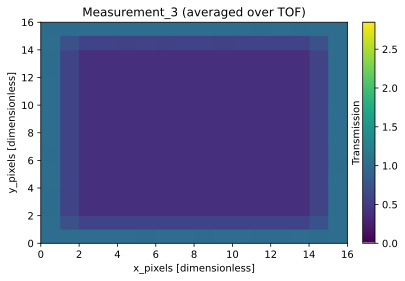

In [11]:
measurement.plot()

By default, this plot is summed over the time-of-flight frames, but a specific time-of-flight can also be plotted

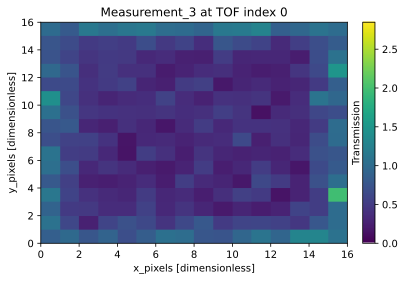

In [12]:
measurement.plot(time_of_flight=0)

Pixels with invalid data values, like infinity or NaN, will appear as red. 
For further customization of the plot, see https://scipp.github.io/plopp/plotting/image-plot.html and https://scipp.github.io/plopp/generated/plopp.plot.html. Any of the arguments supported here is also supported in the `plot` method.

In case of invalid data-points, it can often be beneficial to rebin the data. When rebinning, invalid data-points are ignored when pixels are averaged, yielding clean data-sets without errenous data-points.
EasyImaging only supports rebinning by divisible whole integers, to avoid having to "guess" how much of a transmission belongs to each bin.

In [13]:
measurement.rebin(dimensions={'x': 2, 'y': 2})

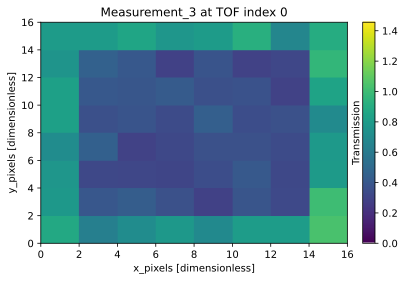

In [14]:
measurement.plot(time_of_flight=0)

Further rebinning will rebin the reduced data-set again, yielding an even rougher binning. Rebinning can be reverted and the original data recovered by using the `revert_rebin` method

In [15]:
measurement.revert_rebin()

A more useful plotter to inspect the different time-of-flight frames is the `slicer_plot`, which is only available in Jupyter notebooks or similar environments with an interactive graphical backend. The `slicer_plot` has a time-of-flight slider to choose the desired frame to plot.

To run it, first add the interactive matplotlib widget to your Jupyter notebook:

In [16]:
%matplotlib widget

Then the slicer plot can be called

In [17]:
measurement.slicer_plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Just like with the regular plot method, any arguments accepted by the underlying plopp backend is supported to further customize the plot, see https://scipp.github.io/plopp/plotting/slicer-plot.html and https://scipp.github.io/plopp/generated/plopp.slicer.html for supported arguments.

To get the time-of-flight spectrum, the **Measurement** provides the `spectrum` method.

In [18]:
measurement.spectrum()

<scipp.DataArray>
Dimensions: Sizes[t:1500, ]
Coordinates:
* Ltotal                      int64              [m]  ()  61
  c                          string        <no unit>  ()  "intensities"
* tof                       float64         [1e-10s]  (t [bin-edge])  [2.15873e+08, 2.16346e+08, ..., 9.24696e+08, 9.25169e+08]
* wavelength                float64             [Å]  (t [bin-edge])  [1.4, 1.40307, ..., 5.99693, 6]
Data:
                            float32  [dimensionless]  (t)  [0.553143, 0.563756, ..., 0.635176, 0.631949]  [8.95489e-06, 9.95399e-06, ..., 3.90536e-05, 3.79215e-05]

By default the `spectrum` method adds up all the pixels of the **Measurement**. 
The method returns a scipp `DataArray` with uncertainties and time-of-flights.

It is also possible to plot the spectrum using the `spectrum_plot` method.

In [19]:
measurement.spectrum_plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Which also accepts plopp supported arguments for plot customization, see: https://scipp.github.io/plopp/plotting/line-plot.html and https://scipp.github.io/plopp/generated/plopp.plot.html

It is also possible to inspect the spectra of individual pixels using the `spectrum_inspector` plot method. This is also an interactive plot which is only supported in Jupyter notebooks and similar. In the plotted **Measurement**, individual pixels can be clicked (after selecting the point-clicker in the menu on the left) to show their spectrum in the spectrum plot underneath.

In [20]:
measurement.spectrum_inspector()

Box(children=(InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(i…

Where again the plot(s) can be customized, see https://scipp.github.io/plopp/plotting/inspector-plot.html and https://scipp.github.io/plopp/generated/plopp.inspector.html

It is also possible to define a region of interest (ROI) to provide the spectrum of a specific designated area. To do this, first the ROI has to be created

In [21]:
from easyimaging.measurement.regions import RectROI

It is possible to define the ROI in code by hand, or draw it by hand (as shown further down)

In [22]:
roi = RectROI(
    x_pixel_range=(15, 35),  # mandatory
    y_pixel_range=(15, 35),  # mandatory
    x_range=(sc.scalar(-0.05, unit='m'), sc.scalar(0.05, unit='m')),  # optional
    y_range=(sc.scalar(-0.05, unit='m'), sc.scalar(0.05, unit='m')),  # optional
    unique_name='center_roi',  # custom name for the ROI, optional, has to be unique in computer memory
)

The ROI needs the x and y pixel ranges, as they are used as fallback for when the ROI is used on a **Measurement** without *x_positions* and *y_positions*. The *x_range* and *y_range* are optional physical ranges which are prioritized when used on a **Measurement** with *x_positions* and *y_positions*.

This ROI can then be passed to the `spectrum` method and the `spectrum_plot` method to only sum up the spectrum of this region.

In [23]:
measurement.spectrum(roi=roi)

<scipp.DataArray>
Dimensions: Sizes[t:1500, ]
Coordinates:
* Ltotal                      int64              [m]  ()  61
  c                          string        <no unit>  ()  "intensities"
* tof                       float64         [1e-10s]  (t [bin-edge])  [2.15873e+08, 2.16346e+08, ..., 9.24696e+08, 9.25169e+08]
* wavelength                float64             [Å]  (t [bin-edge])  [1.4, 1.40307, ..., 5.99693, 6]
Data:
                            float32  [dimensionless]  (t)  [1.01116, 0.937778, ..., 1.19469, 0.721854]  [0.0045393, 0.00403823, ..., 0.0232033, 0.00823131]

In [24]:
measurement.spectrum_plot(roi=roi)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In general, an ROI should be added to a **Measurement** class to be used later in fitting

In [25]:
measurement.regions_of_interest.append(roi)

When the ROI is added to a **Measurement**, it can also be used in `spectrum` and `spectrum_plot` methods by simply passing its unique name

In [26]:
measurement.spectrum_plot(roi='center_roi')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

As prevously promised, the ROI can also be drawn easily by hand, using the `roi_creator` tool. After opening the tool, click the bottom option in the control panel on the left to activate the ROI drawing tool.

Controls when ROI drawing tool is activated:
- Left-click to make new ROI's
- Left-click and hold on ROI vertices to resize ROI's
- Right-click and hold to drag/move the entire ROI
- Middle-click to delete an ROI

In [27]:
measurement.roi_creator()

Box(children=(InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(i…

The ROI's drawn with the `roi_creator` tool will appear in the **Measurements** list of regions of interest with default _unique_names_.

In [28]:
measurement.regions_of_interest

EasyList of length 1 of type(s) [<class 'easyimaging.measurement.regions.RectROI'>]

To easier identify specific ROI's, rename ROI's with memorable unique_names. Be aware that each unique_name can only exist once in memory, if a desired unique_name is currently occupied by another object, you might have to restart the notebook to clear the memory.

In [29]:
figs = measurement.roi_creator()
# Draw a rectangle
figs[0].toolbar['inspect']._tool.start()
figs[0].toolbar['inspect']._tool.click(x=2.5, y=2.5, button=1)
figs[0].toolbar['inspect']._tool.click(x=5.0, y=5.0, button=1)
figs[0].toolbar['inspect']._tool.stop()

In [30]:
measurement.regions_of_interest[1].unique_name = 'best_roi'  # Requires that an ROI was drawn using the roi_creator tool.